## Figure 2 G -
### Expression heatmp FOR PROGRAM 1 perturbations and genes

In [15]:
import h5py
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
file_path = "/project/GCRB/Hon_lab/s438217/cNMF/TF_full/TF_full_mean_gene_expr_all_perturb_all_genes.h5"


with h5py.File(file_path, "r") as f:
    # Load numerical data
    data = f["df/block0_values"][:]
    
    # Decode column (feature) names
    columns = [name.decode("utf-8") for name in f["df/block0_items"][:]]
    
    # Decode row indices
    index = [name.decode("utf-8") for name in f["df/axis1"][:]]

# Create DataFrame
expression_matrix = pd.DataFrame(data, index=index, columns=columns)
expression_matrix = expression_matrix.T

# Avoid division by zero by replacing zeros with a small value

In [4]:
TF_full_usage = pd.read_csv("/home2/s438217/jupyter_notebooks/jupyter_notebooks_backup/IGVF_analysis/TF_perturb_seq_full/figures_for_paper/usage_score_update_chikara_211_targets.csv")


In [7]:


# Replace 'your_file.pkl' with the path to your .pkl file
with open('/project/GCRB/Hon_lab/s438217/cNMF/TF_full/TF_perturb_full/usage_per_perturbation_k_all_targets_clear_gRNA_12_3_24.pkl', 'rb') as file:
    perturbation_score = pickle.load(file)

# Now 'data' contains the content of the pickle file
perturbation_score_250 = perturbation_score['result_k_250']
perturbation_score_250 = perturbation_score_250.sort_values(by="Usage_1")


In [8]:
perturbation_score_250 = perturbation_score_250.sort_values(by = "Usage_1")
perturbation_score_211 = perturbation_score_250[perturbation_score_250.index.isin(TF_full_usage["Unnamed: 0"])]
perturbation_score_211 =  perturbation_score_211.sort_values(by = "Usage_1")
heatmap_expr = expression_matrix[expression_matrix.index.isin(perturbation_score_211.index)]
heatmap_expr = heatmap_expr.reindex(perturbation_score_211.index)

In [9]:
low_usage = perturbation_score_211[(perturbation_score_211['Usage_1'] < 0.167) ]
high_usage = perturbation_score_211[(perturbation_score_211['Usage_1'] >0.167) ]
low_usage = low_usage.sort_values(by = "Usage_1")
high_usage = high_usage.sort_values(by = "Usage_1")

low_usage_gene_expr = heatmap_expr.loc[low_usage.index,:]
high_usage_gene_expr = heatmap_expr.loc[high_usage.index,:]

In [11]:
low_usage_gene_expr_avg = low_usage_gene_expr.mean(axis=0)
high_usage_gene_expr_avg = high_usage_gene_expr.mean(axis=0)
metarows_low_high = pd.DataFrame([low_usage_gene_expr_avg, high_usage_gene_expr_avg], index=['low_usage', 'high_usage'])


In [12]:
std_between_metarows = metarows_low_high.std()
std_between_metarows = pd.DataFrame(std_between_metarows)
std_between_metarows = std_between_metarows.sort_values(ascending=False,by = 0)
std_between_metarows = std_between_metarows.loc[std_between_metarows[0] != 0]
std_between_metarows = std_between_metarows.sort_values(ascending=False,by = 0)
top_500 = std_between_metarows.head(500)
rows_of_interest_heatmap = heatmap_expr.loc[:,top_500.index]


In [13]:
gene_usage = pd.read_csv("/project/GCRB/Hon_lab/s438217/cNMF/cNMF_output_files/tf_perturb/tf_perturb.gene_spectra_score.k_250.dt_0_1.txt", sep='\t', index_col=0)
usage_1_genes = gene_usage.iloc[0:1,:]
usage_1_genes = usage_1_genes.T
usage_1_genes  = usage_1_genes.sort_values(by =1)


In [14]:
usage1_500 = usage_1_genes[usage_1_genes.index.isin(rows_of_interest_heatmap.columns)]
ordered_genes = usage1_500.index
df_genes_reordered = rows_of_interest_heatmap.loc[:,ordered_genes]

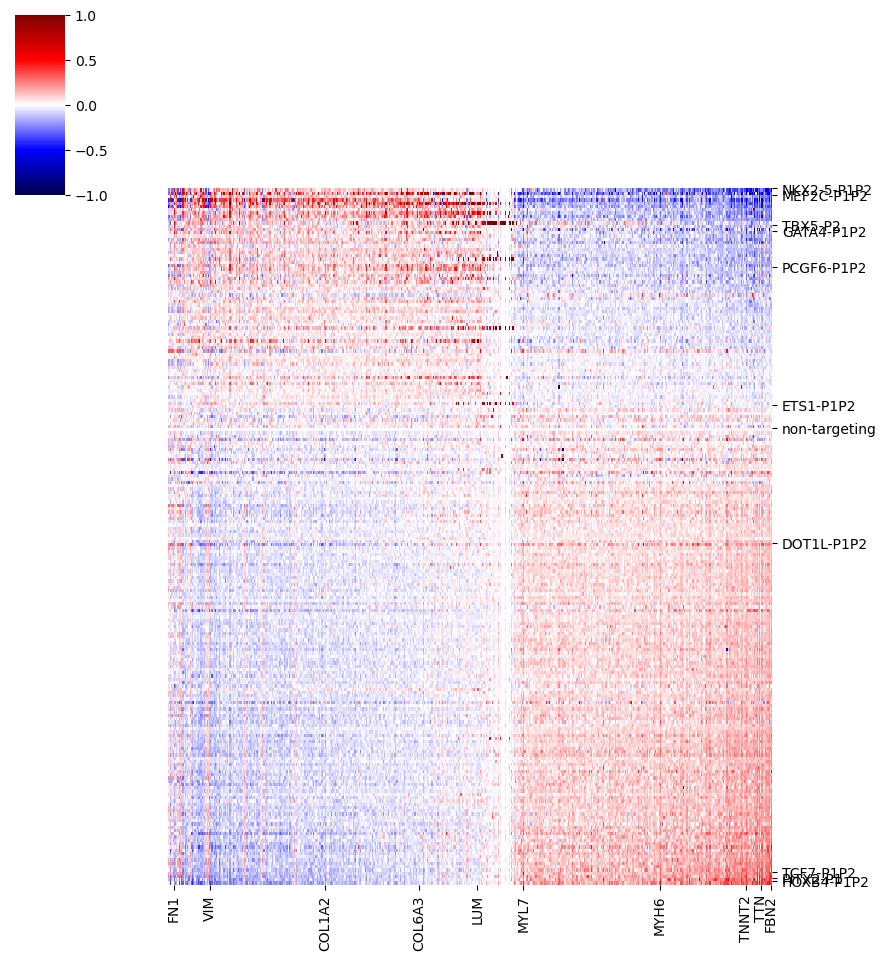

In [16]:


# Define rows and columns to label
selected_rows = ["TBX5-P2","NKX2-5-P1P2","GATA4-P1P2","MEF2C-P1P2","PCGF6-P1P2","ETS1-P1P2","DOT1L-P1P2","non-targeting","TCF7-P1P2","PITX2-P1","HOXB4-P1P2"]  # Replace with actual row names
selected_columns = ["COL1A2","COL6A3","TTN","FBN2","FN1","VIM","TNNT2","MYL7","MYH6","LUM"]  # Replace with actual column names

# Generate clustermap
cluster = sns.clustermap(df_genes_reordered, 
                         method="complete", 
                         row_cluster=False, 
                         col_cluster=False, 
                         cmap="seismic", 
                         vmin=-1, 
                         vmax=1, 
                         center=0)

# Get axis objects
ax = cluster.ax_heatmap

# Find y-tick positions for selected rows
row_labels = df_genes_reordered.index.tolist()
yticks = [row_labels.index(label) for label in selected_rows if label in row_labels]

# Set y-axis labels only for selected rows
ax.set_yticks(yticks)
ax.set_yticklabels(selected_rows, fontsize=10)

# Find x-tick positions for selected columns
col_labels = df_genes_reordered.columns.tolist()
xticks = [col_labels.index(label) for label in selected_columns if label in col_labels]

# Set x-axis labels only for selected columns
ax.set_xticks(xticks)
ax.set_xticklabels(selected_columns, fontsize=10, rotation=90)

#pdf_path = "/project/GCRB/Hon_lab/s438217/cNMF/TF_full_cNMF_figure_2_plots/program1_clustermap_selected_labels_3_10_25.pdf"  # Change path if needed
#plt.savefig(pdf_path, dpi=300, bbox_inches="tight", format="pdf")

#print(f"Heatmap saved as {pdf_path}")

# Show plot
plt.show()
